#Lineer Regresyon

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dosya_yolu="../data/raw/linear-regression-dataset.csv"
data=pd.read_csv(dosya_yolu)

In [ ]:
data

,deneyim,maas
0,0.5,2500
1,0.0,2250
2,1.0,2750
3,5.0,8000
4,8.0,9000
5,4.0,6900
6,15.0,20000
7,7.0,8500
8,3.0,6000
9,2.0,3500


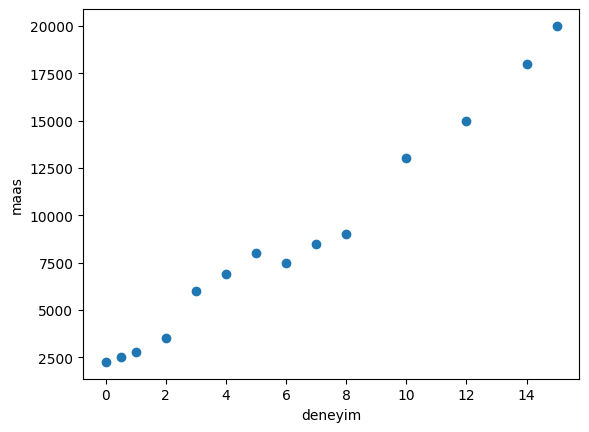

In [ ]:
deneyim=data["deneyim"]
maas=data["maas"]

plt.scatter(deneyim,maas)
plt.xlabel("deneyim")
plt.ylabel("maas")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression  # Lineer regresyon modelini kullanmak icin gerekli sinifi ice aktarir

lr = LinearRegression()  # Lineer regresyon model nesnesini olusturur

X = data.deneyim.values.reshape(-1, 1)  # Bagimsiz degiskeni (deneyim) numpy array'e cevirir ve 2 boyutlu hale getirir
Y = data.maas.values.reshape(-1, 1)     # Bagimli degiskeni (maas) numpy array'e cevirir ve 2 boyutlu hale getirir

lr.fit(X, Y)  # Lineer regresyon modelini X ve Y verileri ile egitir

skor = lr.score(X, Y)  # Modelin R^2 (belirleme katsayisi) skorunu hesaplar
print(skor)            # Hesaplanan R^2 skorunu ekrana yazdirir

b0 = lr.intercept_     # Regresyon dogrusunun sabit terimini (b0) alir
b1 = lr.coef_          # Regresyon dogrusunun egimini (b1) alir

print(b0)              # Sabit terimi ekrana yazdirir
print(b1)              # Eğim degerini ekrana yazdirir

print("Regresyon denklemi Y=" + str(b0) + "+" + str(b1) * "X")  # Elde edilen b0 ve b1 degerleri ile regresyon denklemini ekrana yazdirir

0.9775283164949903
[1663.89519747]
[[1138.34819698]]
Regresyon denklemi Y=[1663.89519747]+[[1138.34819698]]X


In [ ]:
deneyim9 = 1663.89519747 + 1138.34819698 * 9  # Regresyon denklemine gore deneyim=9 icin maas tahminini hesaplar
deneyim9                                   # Hesaplanan maas tahminini ekrana dondurur

11909.028970289999

In [ ]:
deneyim9 = lr.predict([[9]])  # Egitilmis lineer regresyon modelini kullanarak deneyim=9 icin maas tahmini yapar
deneyim9                     # Modelin urettigi maas tahminini ekrana dondurur

array([[11909.02897025]])

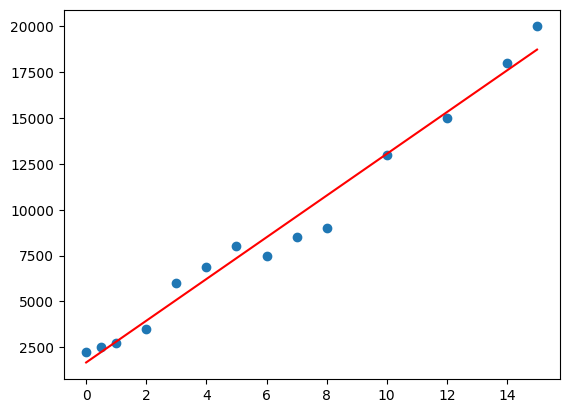

In [ ]:
array = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]).reshape(-1, 1)  # 0–15 arasindaki degerleri iceren numpy dizisini olusturur ve 2 boyutlu hale getirir

plt.scatter(X, Y)  # Gercek deneyim-maas verilerini nokta (scatter) olarak cizer

tahminEdilen = lr.predict(array)  # Olusturulan deneyim degerleri icin maas tahminleri yapar
plt.plot(array, tahminEdilen, color="red")  # Tahmin edilen regresyon dogrusunu kirmizi cizgi ile cizer

plt.show()  # Noktalar ve regresyon dogrusunu ayni grafikte ekranda gosterir

In [ ]:
lr.predict([[20]])  # Egitilmis lineer regresyon modelini kullanarak deneyim=20 icin maas tahmini yapar

array([[24430.85913699]])

In [ ]:
from sklearn.metrics import mean_squared_error                 # Ortalama karesel hata (MSE) hesaplamak icin kullanilir
from sklearn.metrics import r2_score                            # R2 (belirleme katsayisi) hesaplamak icin kullanilir
from sklearn.metrics import mean_absolute_error                 # Ortalama mutlak hata (MAE) hesaplamak icin kullanilir
from sklearn.metrics import mean_absolute_percentage_error      # Ortalama mutlak yuzde hata (MAPE) hesaplamak icin kullanilir
from sklearn.metrics import root_mean_squared_error             # Kok ortalama karesel hata (RMSE) hesaplamak icin kullanilir
from sklearn.model_selection import train_test_split            # Veriyi egitim ve test olarak ayirmak icin kullanilir
from sklearn.linear_model import LinearRegression                # Lineer regresyon modelini kullanmak icin kullanilir

import pandas as pd                                             # Veri okuma ve isleme icin pandas kutuphanesi
import numpy as np                                              # Sayisal islemler icin numpy kutuphanesi
import matplotlib.pyplot as plt                                 # Grafik cizimi icin matplotlib
import seaborn as sns                                           # Gelismis grafikler icin seaborn

dosya_yolu = "../data/raw/linear-regression-dataset.csv"           # Veri setinin bulundugu dosya yolunu belirtir
data = pd.read_csv(dosya_yolu)                                  # CSV dosyasini okuyarak DataFrame haline getirir

lr = LinearRegression()                                         # Lineer regresyon model nesnesini olusturur

X = data.deneyim.values.reshape(-1, 1)                          # Bagimsiz degiskeni (deneyim) 2 boyutlu hale getirir
Y = data.maas.values.reshape(-1, 1)                             # Bagimli degiskeni (maas) 2 boyutlu hale getirir

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=0
)                                                               # Veriyi %80 egitim, %20 test olarak ayirir

lr.fit(X_train, Y_train)                                        # Modeli egitim verileri ile egitir

Y_pred = lr.predict(X_test)                                     # Test verileri icin maas tahminleri yapar

r2 = r2_score(Y_test, Y_pred)                                   # Modelin R2 degerini hesaplar
print("r2 degeri: ", r2)                                        # R2 degerini ekrana yazdirir

mse = mean_squared_error(Y_test, Y_pred)                        # Ortalama karesel hatayi hesaplar
print("mse degeri: ", mse)                                      # MSE degerini ekrana yazdirir

rmse = np.sqrt(mse)                                             # MSE'nin karekokunu alarak RMSE hesaplar
print("rmse degeri: ", rmse)                                    # RMSE degerini ekrana yazdirir

mae = mean_absolute_error(Y_test, Y_pred)                       # Ortalama mutlak hatayi hesaplar
print("mae degeri: ", mae)                                      # MAE degerini ekrana yazdirir

mape = mean_absolute_percentage_error(Y_test, Y_pred)           # Ortalama mutlak yuzde hatayi hesaplar
print("mape degeri: ", mape)                                    # MAPE degerini ekrana yazdirir

r2 degeri:  0.9455565414771729
mse degeri:  1972063.0531601794
rmse degeri:  1404.3016247089438
mae degeri:  1363.6851222599787
mape degeri:  0.13733128641333722


{'Lineer Regresyon': {'r2': 0.9455565414771729, 'mse': 1972063.0531601794, 'rmse': np.float64(1404.3016247089438), 'mae': 1363.6851222599787, 'mape': 0.13733128641333722}, 'Ridge': {'r2': 0.9448267966321674, 'mse': 1998496.0331014923, 'rmse': np.float64(1413.6817297756565), 'mae': 1370.862354892206, 'mape': 0.1369584484982495}, 'Lasso': {'r2': 0.9455495308156637, 'mse': 1972316.9948992927, 'rmse': np.float64(1404.392037466495), 'mae': 1363.7562129389023, 'mape': 0.13732759344393353}, 'SVR': {'r2': -0.47884753063734364, 'mse': 53567143.887530446, 'rmse': np.float64(7318.957841628167), 'mae': 5164.57166917748, 'mape': 0.34695565443960286}, 'DecisionTreeRegressor': {'r2': 0.9033742331288344, 'mse': 3500000.0, 'rmse': np.float64(1870.8286933869706), 'mae': 1666.6666666666667, 'mape': 0.19074074074074077}}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


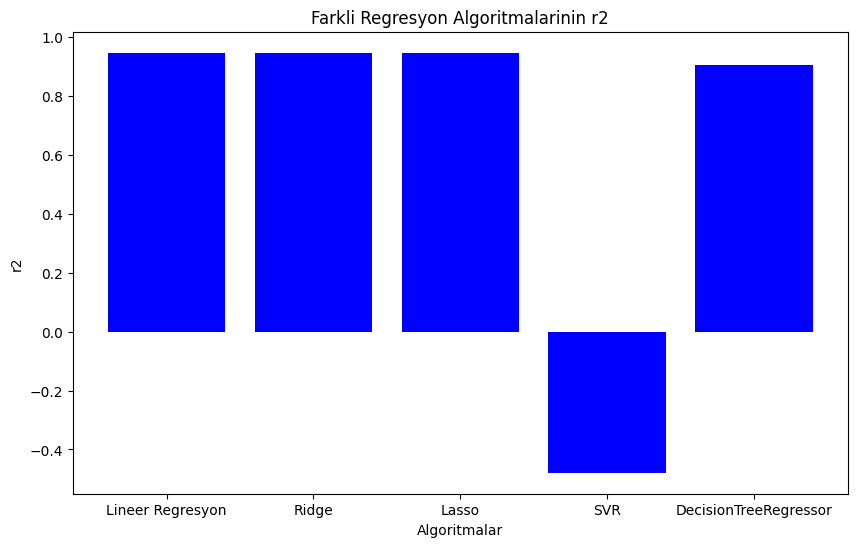

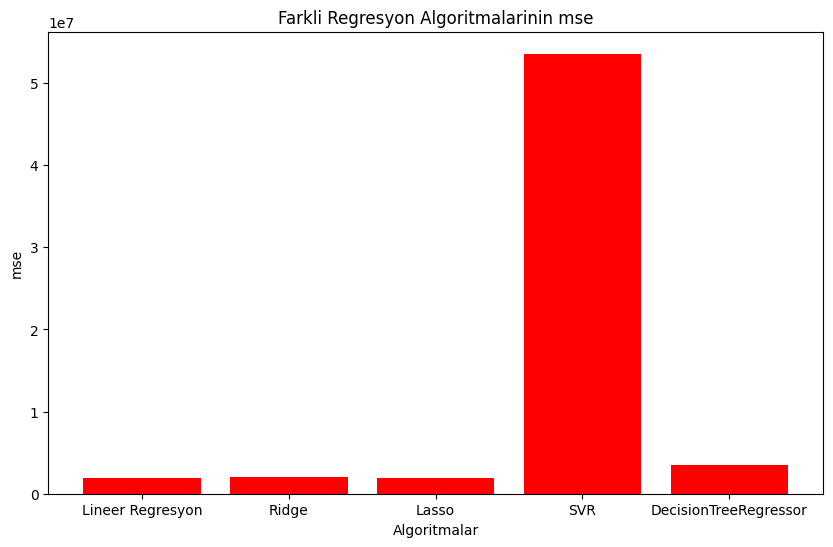

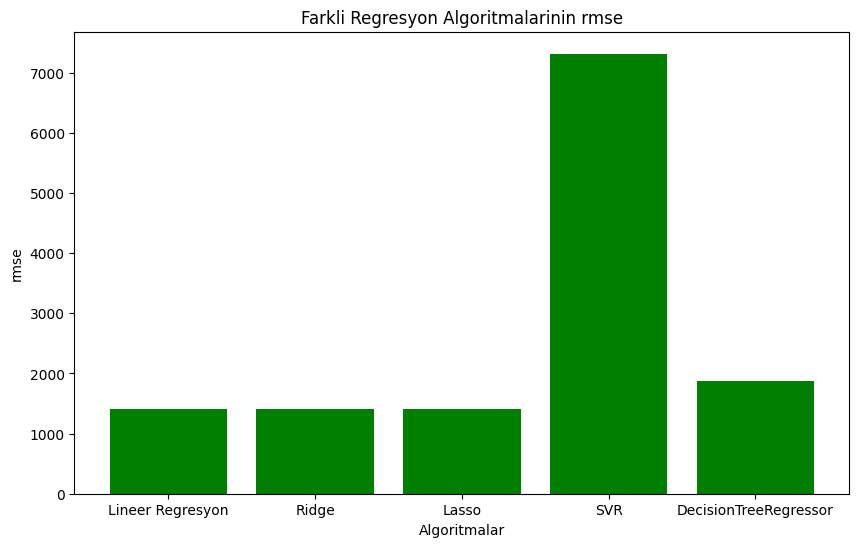

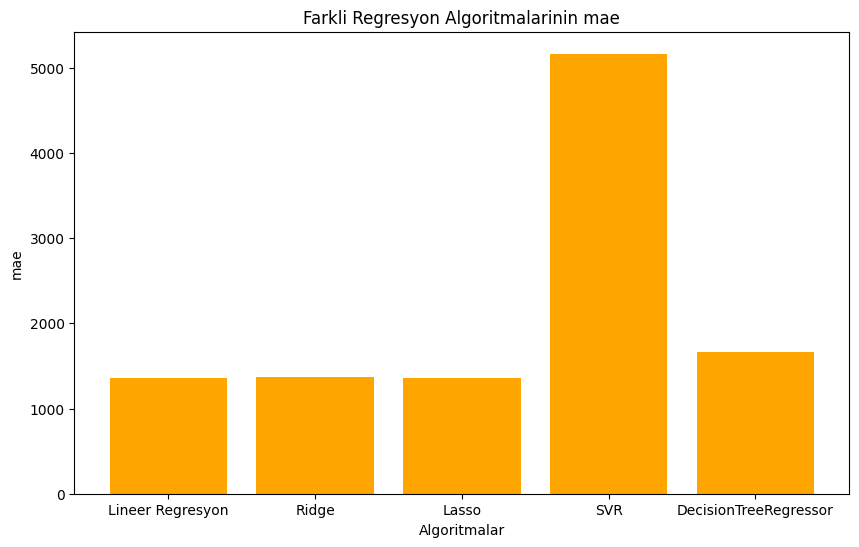

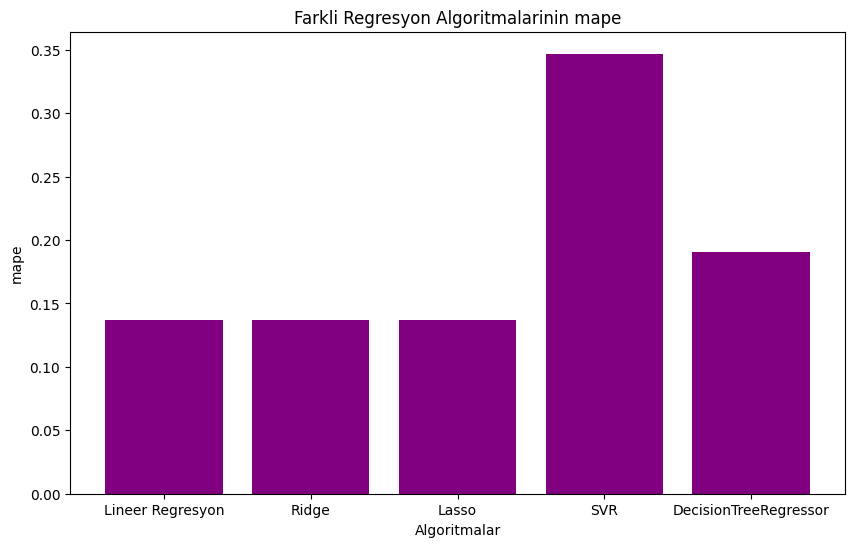

In [ ]:
from sklearn.metrics import mean_squared_error                 # Ortalama karesel hata (MSE) hesaplamak icin kullanilir
from sklearn.metrics import r2_score                            # R2 (belirleme katsayisi) hesaplamak icin kullanilir
from sklearn.metrics import mean_absolute_error                 # Ortalama mutlak hata (MAE) hesaplamak icin kullanilir
from sklearn.metrics import mean_absolute_percentage_error      # Ortalama mutlak yuzde hata (MAPE) hesaplamak icin kullanilir
from sklearn.metrics import root_mean_squared_error             # Kok ortalama karesel hata (RMSE) hesaplamak icin kullanilir
from sklearn.model_selection import train_test_split            # Veriyi egitim ve test olarak ayirmak icin kullanilir
from sklearn.linear_model import LinearRegression, Ridge, Lasso # Lineer, Ridge ve Lasso regresyon modelleri
from sklearn.svm import SVR                                     # Support Vector Regression modeli
from sklearn.tree import DecisionTreeRegressor                  # Karar agaci tabanli regresyon modeli

dosya_yolu = "../data/raw/linear-regression-dataset.csv"           # Veri setinin bulundugu dosya yolunu belirtir
data = pd.read_csv(dosya_yolu)                                  # CSV dosyasini okuyarak DataFrame haline getirir

X = data.deneyim.values.reshape(-1, 1)                          # Bagimsiz degiskeni (deneyim) 2 boyutlu hale getirir
Y = data.maas.values.reshape(-1, 1)                             # Bagimli degiskeni (maas) 2 boyutlu hale getirir

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=0
)                                                               # Veriyi %80 egitim, %20 test olarak ayirir

models = {                                                      # Kullanilacak regresyon modellerini sozluk halinde tanimlar
    "Lineer Regresyon": LinearRegression(),                     # Klasik lineer regresyon modeli
    "Ridge": Ridge(),                                           # L2 regularizasyonlu regresyon modeli
    "Lasso": Lasso(),                                           # L1 regularizasyonlu regresyon modeli
    "SVR": SVR(),                                               # Support Vector Regression modeli
    "DecisionTreeRegressor": DecisionTreeRegressor()            # Karar agaci tabanli regresyon modeli
}

performance_metrics = {}                                        # Tum modellerin performanslarini tutacak bos sozluk

for name, model in models.items():                              # Her model icin dongu baslatir
    model.fit(X_train, Y_train)                                 # Modeli egitim verisi ile egitir
    Y_pred = model.predict(X_test)                              # Test verileri icin tahmin yapar

    r2 = r2_score(Y_test, Y_pred)                               # R2 degerini hesaplar
    mse = mean_squared_error(Y_test, Y_pred)                    # MSE degerini hesaplar
    rmse = np.sqrt(mse)                                         # RMSE degerini hesaplar
    mae = mean_absolute_error(Y_test, Y_pred)                   # MAE degerini hesaplar
    mape = mean_absolute_percentage_error(Y_test, Y_pred)       # MAPE degerini hesaplar

    performance_metrics[name] = {                               # Her model icin metrikleri sozlukte saklar
        "r2": r2,
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "mape": mape
    }

print(performance_metrics)                                      # Tum modellerin performans metriklerini ekrana yazdirir

r2degerleri = [metrik["r2"] for metrik in performance_metrics.values()]      # Tum modellerin r2 degerlerini listeye atar
msedegerleri = [metrik["mse"] for metrik in performance_metrics.values()]    # Tum modellerin mse degerlerini listeye atar
rmsedegerleri = [metrik["rmse"] for metrik in performance_metrics.values()]  # Tum modellerin rmse degerlerini listeye atar
maedegerleri = [metrik["mae"] for metrik in performance_metrics.values()]    # Tum modellerin mae degerlerini listeye atar
mapedegerleri = [metrik["mape"] for metrik in performance_metrics.values()]  # Tum modellerin mape degerlerini listeye atar
algoritmalar = list(performance_metrics.keys())                              # Model isimlerini listeye cevirir

def plot_metrik(metrik_adi, metrik_degerleri, renk):            # Verilen metrik icin bar grafik cizen fonksiyon
    plt.figure(figsize=(10, 6))                                 # Grafik boyutunu ayarlar
    plt.bar(algoritmalar, metrik_degerleri, color=renk)         # Algoritmalara gore bar grafik cizer
    plt.xlabel("Algoritmalar")                                  # X ekseni adini belirler
    plt.ylabel(metrik_adi)                                      # Y ekseni adini metrik adi olarak belirler
    plt.title(f"Farkli Regresyon Algoritmalarinin {metrik_adi}") # Grafigin basligini belirler
    plt.show()                                                  # Grafigi ekranda gosterir

plot_metrik("r2", r2degerleri, "blue")                           # R2 degerleri icin grafik cizer
plot_metrik("mse", msedegerleri, "red")                          # MSE degerleri icin grafik cizer
plot_metrik("rmse", rmsedegerleri, "green")                     # RMSE degerleri icin grafik cizer
plot_metrik("mae", maedegerleri, "orange")                      # MAE degerleri icin grafik cizer
plot_metrik("mape", mapedegerleri, "purple")                    # MAPE degerleri icin grafik cizer


In [ ]:
models={
    "Lineer Regresyon":LinearRegression(),
    "Ridge":Ridge(),
    "Lasso":Lasso(),
    "SVR":SVR(),
    "DecisionTreeRegressor":DecisionTreeRegressor(),
    "RandomForestRegressor":RandomForestRegressor(),
    "XGBRegressor":XGBRegressor(),
    "CatBoostRegressor":CatBoostRegressor(),
    "LightGBMRegressor":LightGBMRegressor(),
    "GradientBoostingRegressor":GradientBoostingRegressor(),
    "AdaBoostRegressor":AdaBoostRegressor(),
    "ExtraTreesRegressor":ExtraTreesRegressor(),
    "Elastic Net":ElasticNet(),
    "KNeighborsRegressor":KNeighborsRegressor(),
    "MLPRegressor":MLPRegressor()
} # Hoca bunları çok kullanıyomuş.